# L'intercanvi de clau CSIDH

En aquest quadern implementarem de manera senzilla CSIDH i donarem alguns exemples per diferents paràmetres. També generarem els grafs $G^{(\ell_i)}$ i les taules de distribució de claus privades.

La implementació de l'intercanvi de clau es basa en l'script `supersingular.sage` de la implementació original de CSIDH (https://yx7.cc/code/csidh/csidh-20180427.tar.xz). En canvi, sí que s'ha implementat des de zero la generació dels grafs, les taules de distribució i els exemples.


## Implementació


En aquesta secció implementarem l'intercanvi de clau CSIDH i els mètodes per generar els grafs i la distribució de claus.

Primer, importem els mòduls necessaris:

In [1]:
import networkx as nx  # Per als grafs
import itertools as it  # Per a la distribució de claus

### Intercanvi de clau

En aquesta secció implementam l'intercanvi de clau CSIDH. Tots els codis d'aquesta secció s'han extret de l'script `supersingular.sage`.

Aquesta implementació considera dues simplificacions a tenir en compte. La primera és que es treballa sobre $\mathbb{F}_{p^2}$ en comptes de $\mathbb{F}_p$ (recordem que la implementació es pot fer sobre $\mathbb{F}_p$ emprant twists quadràtics). La segona és que, al igual que al quadern `intro.ipynb`, no s'implementa l'aritmètica de Montgomery i, per tant, Sage treballarà amb el model de Weierstrass.

Per començar, crearem una funció per configurar els paràmetres. S'ha de donar un llistat de nombres primers senars diferents $\ell_1,\ldots,\ell_n$, i llavors es calcula $p = 4\cdot\ell_1\cdots\ell_n-1$, $m$ (el rang màxim dels exponents de la clau privada), $E_0$, i $\mathbb{F}_{p^2}$.  


In [2]:
def set_params(primers):
    global ls, p, max_exp, base, Fp2

    # Es calcula p i es comprova que sigui primer
    ls = primers
    p = 4 * prod(ls) - 1
    assert is_prime(p)
    print("Primers:", " ".join(map(str, ls)))
    print("p =", p)

    # Rang d'enters per la clau privada
    max_exp = ceil((sqrt(p) ** (1/len(ls)) - 1) / 2)
    assert (2 * max_exp + 1) ** len(ls) >= sqrt(p)
    print(f"Rang per als exponents: {{{-max_exp},...,{max_exp}}}")

    # E_0 i Fp2
    base = GF(p)(0) # Coeficient de Montgomery de la corba inicial
    Fp2.<i> = GF(p**2, modulus = x**2 + 1)

Seguidament, donam les funcions per treballar amb corbes de Montgomery (tal com al quadern `intro.ipynb`):

In [3]:
# A partir de A, retorna E_A: y**2 = x**3 + A x**2 + x
def montgomery_curve(A):
    return EllipticCurve(Fp2, [0, A, 0, 1, 0])

# A partir de E, obté el coeficient de Mongomery A
# (en cas que E sigui una corba de Montgomery)
def montgomery_coefficient(E):
    Ew = E.change_ring(GF(p)).short_weierstrass_model()
    _, _, _, a, b = Ew.a_invariants()
    R.<z> = GF(p)[]
    r = (z**3 + a*z + b).roots(multiplicities=False)[0]
    s = sqrt(3 * r**2 + a)
    if not is_square(s): s = -s
    A = 3 * r / s
    assert montgomery_curve(A).change_ring(GF(p)).is_isomorphic(Ew)
    return GF(p)(A)

Recordem que a CSIDH es considera l'acció repetida dels ideals $\mathfrak{l}_i=\langle\ell_i,\pi-1\rangle$ i $\overline{\mathfrak{l}_i}=\langle\ell_i,\pi+1\rangle$. A la pràctica, un genera aleatòriament una tupla $(e_1,\ldots,e_n)$ amb totes les components dins un rang d'enters $\{-m,\ldots,m\}$ i es calcula l'acció de $[\mathfrak{l}_1^{e_1}\cdots\mathfrak{l}_k^{e_n}]$ (recordem que $[\overline{\mathfrak{l}_i}]=[\mathfrak{l}_i]^{-1}$).

A continuació donam la implementació de l'Algoritme 1 de la memòria, que ens calcula l'acció de Waterhouse de $[\mathfrak{l}_1^{e_1}\cdots\mathfrak{l}_k^{e_n}]$.


In [4]:
# Acció de Waterhouse a CSIDH
# - pub: la corba el·líptica
# - priv: la classe d'ideals
def action(pub, priv):
    E = montgomery_curve(pub)
    es = priv[:]
    while any(es):
        E._order = (p + 1)**2 # (Per evitar que Sage ho calculi)

        P = E.lift_x(GF(p).random_element())
        s = +1 if P.xy()[1] in GF(p) else -1
        k = prod(l for l, e in zip(ls, es) if sign(e) == s)
        P *= (p + 1) // k

        for i, (l, e) in enumerate(zip(ls, es)):
            if sign(e) != s: continue
            Q = k // l * P
            if not Q: continue
            Q._order = l # (Per evitar que Sage ho calculi)
            phi = E.isogeny(Q)
            E, P = phi.codomain(), phi(P)
            es[i] -= s
            k //= l

    return montgomery_coefficient(E)

Finalment, donam un mètode per dur a terme un intercanvi de clau CSIDH. Notem que les claus privades s'haurien de generar aleatòriament, però en aquest quadern ens interessa que els exemples siguin fixats.


In [5]:
# Executa un intercanvi de clau CSIDH a partir d'unes claus privades
def csidh(privA, privB):
    # Claus de n'Alba
    # privA = [randrange(-max_exp, max_exp + 1) for _ in range(len(ls))]
    print("Clau privada de n'Alba:    ", " ".join(map('{:2d}'.format, privA)))
    
    pubA = action(base, privA)
    print("Clau pública de n'Alba:    ", pubA)
    
    # Claus d'en Biel
    # privB = [randrange(-max_exp, max_exp + 1) for _ in range(len(ls))]
    print("Clau privada d'en Biel:    ", " ".join(map('{:2d}'.format, privB)))
    
    pubB = action(base, privB)
    print("Clau pública d'en Biel:    ", pubB)
    

    # Clau compartida calculada per n'Alba
    sharedA = action(pubB, privA)
    print("Secret compartit (Alba):   ", sharedA)
    
    # Clau compartida calculada per en Biel
    sharedB = action(pubA, privB)
    print("Secret compartit (Biel):   ", sharedB)
    
    # Comprovam que hagin generat a mateixa clau
    if sharedA == sharedB:
        print("\n--> EL SECRET COINCIDEIX!")
    else:
        print("\n--> EL SECRET NO COINCIDEIX?!")


### Grafs

Recordem que els nodes del graf $G^{(\ell_i)}$ són les classes de ECs supersingulars $\mathbb{F}_p$-isomorfes, representades pel seu coeficient de Montgomery \($E_A : y^2=x^3+A x^2  + x$\), i hi ha una aresta entre dos nodes $A$  i $B$ si, i només si, existeix una isogènia de grau $\ell_i$ entre $E_A$ i $E_B$. 

Primer, crearem un mètode per obtenir totes les corbes supersingulars amb anell de $\mathbb{F}_p$\-endomorfismes isomorf a $\mathbb{Z}[\sqrt{-p}]$, és a dir, els nodes dels grafs. Aquest mètode pren tots els nombres possibles $A\in\mathbb{F}_p\setminus\{\pm2\}$ i comprova si $E_A$ és supersingular o no. Notem que es pot reduir la cerca a la meitat emprant el fet que el twist quadràtic de $E_A$ és $E_{-A}$, i aquest preserva la supersingularitat.


In [6]:
def montgomery_supersingulars():
    supersingulars = [0]
    for A in range(1, p // 2 + 1): # Basta fins la meitat, l'altra són els quadratic twists
        if A != 2 and montgomery_curve(A).is_supersingular():
            # Afegim E_A i el seu twist quadràtic
            supersingulars.append(A)
            supersingulars.append(p - A)
            
    return supersingulars


Ara, recordem també que podem generar el graf $G^{(\ell_i)}$ aplicant l'acció de $[\mathfrak{l}_i]$ i $[\overline{\mathfrak{l}_i}]$ sobre cada node. Per tant, tot seguit donam un mètode per obtenir els cicles que generam d'aquesta manera.


In [7]:
# Calcula els cicles que genera l'acció de `priv` sobre cada corba
def cicles_accio(corbes, priv):
    c = corbes.copy()
    cicles = []
    while c: 
        # Mentre encara quedin corbes, agafam la primera i calculam el seu cicle
        A = c[0]
        cicle = [A]
        del c[0]
        while True:  # Calculam l'acció repetidament fins obtenir el cicle
            A = action(A, priv)
            if A == cicle[0]:  # Si A == cicle[0], ja haurem tancat el cicle
                break

            # Afegim la corba al cicle i l'eliminam de les corbes pendents
            cicle.append(A)
            c.remove(A)

        # Afegim el cicle al conjunt de cicles
        cicles.append(cicle)
        
    return cicles

Abans de dibuixar els grafs $G^{(\ell_i)}$, crearem la funció auxiliar següent per afegir-hi tot un llistat de cicles \(idò estam interessats en dibuixar els cicles que ha generat l'acció de cada $\mathfrak{l}_i$\). A més, afegirem a les arestes d'aquests cicles un color, per distingir els graus de les isogènies.



In [8]:
# Afegeix un conjunt de cicles a un graf G (networkx) amb un determinat color
def cicles_dibuixar(G, cicles, col):
    for cicle in cicles:
        orig = cicle[0]
        for i in range(1, len(cicle)):
            # Anam afegint les arestes del cicle
            G.add_edge(orig, cicle[i], color=col)
            orig = cicle[i]

        # Afegim la darrera aresta, tancant el cicle
        G.add_edge(orig, cicle[0], color=col)

Finalment, donam els mètodes per crear i dibuixar el graf.

In [9]:
# Construeix un graf a aprtir d'uns cicles. Cada cicle té un color associat.
def graf_crear(cicles, colors):
    G = nx.DiGraph()  # Inicialitzam un graf dirigit
    
    # Afegim els cicles al graf, cadascun amb el seu color
    for i in range(len(cicles)):
        cicles_dibuixar(G, cicles[i], colors[i])

    return G

# Dibuixa un graf generat per `crear_graf`
def graf_dibuixar(G, **kwargs):
    pos = nx.circular_layout(G)  # Plantilla circular
    colors = [G[u][v]['color'] for u,v in G.edges]  # Colors de les arestes
    nx.draw(G, pos, edge_color=colors, node_color='#0f0', **kwargs)  # Dibuixam G

### Distribució de claus

El mètode següent obté la distribució de claus privades.

In [10]:
# Retorna totes les claus privades possibles (n-tuples de valors enters entre -m i m) per cada clau pública.
def distribucio_claus(n, m):
    # Diccionari amb el format `corba: [clau1, clau2, ...]`
    distribucio = {}

    # Provam totes les claus privades possibles
    for priv in it.product(range(-m, m+1), repeat=n):
        # Calculam el resultat i afegim aquesta corba al diccionari
        corba = action(base, list(priv))
        if corba not in distribucio:
            distribucio[corba] = [priv]
        else:
            distribucio[corba].append(priv)

    return distribucio
        

## Exemple amb $p=83$



Començam amb un exemple petit, amb primers $\ell_1=3$ i $\ell_2=7$. Primer, configuram els paràmetres i obtenim el conjunt de corbes de Montgomery supersingulars.


In [11]:
set_params([3, 7])
corbes = montgomery_supersingulars()
print()
print(f"Corbes supersingulars ({len(corbes)}):")
print(corbes)

Primers: 3 7
p = 83
Rang per als exponents: {-2,...,2}

Corbes supersingulars (9):
[0, 6, 77, 11, 72, 12, 71, 13, 70]


Ara, per dibuixar el graf ens interessa veure els cicles que genera l'acció de cada $\mathfrak{l}_i$ \(corresponents a les isogènies de grau $\ell_i$\):


In [12]:
l1 = cicles_accio(corbes, [1, 0]); # Acció de l1(=l1^1 l2^0)
l2 = cicles_accio(corbes, [0, 1]); # Acció de l2(=l1^0 l2^1)
print("Acció per l1:", l1)
print("Acció per l2:", l2)

Acció per l1: [[0, 72, 71, 77, 13, 70, 6, 12, 11]]
Acció per l2: [[0, 70, 72, 6, 71, 12, 77, 11, 13]]


A continuació dibuixam el graf (unió de $G^{(3)}$ i $G^{(7)}$). Els nodes s'han etiquetat amb el coeficient de Montgomery, i les arestes corresponents a isogènies de grau 3 s'han dibuixat en blau i les de grau 7 en verd. D'aquesta manera, obtindrem el graf de la Figura 3.1 de la memòria.

Recordem que consideram aquests grafs no dirigits. Emperò, afegirem un sentit a les arestes per distingir l'acció de $[\mathfrak{l}_i^{+1}]$ (seguint el sentit) de l'acció de $[\mathfrak{l}_i^{-1}]$ (en sentit contrari).



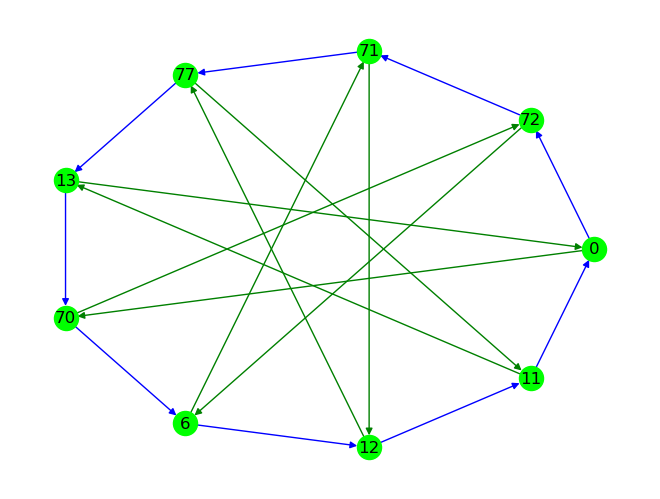

In [13]:
G83 = graf_crear([l1, l2], ['blue', 'green'])
graf_dibuixar(G83, with_labels=True)

Ara, donarem la distribució de claus per aquests paràmetres, generant així la Taula 3.1 de la memòria. Aquesta distribució es pot comprovar perfectament en el graf.

In [14]:
distribucio_claus(len(ls), max_exp)

{6: [(-2, -2), (1, 1), (2, -1)],
 71: [(-2, -1), (1, 2), (2, 0)],
 12: [(-2, 0), (-1, -2), (2, 1)],
 77: [(-2, 1), (-1, -1), (2, 2)],
 11: [(-2, 2), (-1, 0), (0, -2)],
 13: [(-1, 1), (0, -1)],
 0: [(-1, 2), (0, 0), (1, -2)],
 70: [(0, 1), (1, -1)],
 72: [(0, 2), (1, 0), (2, -2)]}

Finalment, amb aquests paràmetres realitzarem un intercanvi de clau. La idea d'aquest petit exemple és poder seguir les operacions de n'Alba i en Biel damunt el graf. Suposem que les claus privades de n'Alba i en Biel són $(2,0)$ i $(-1,1)$, respectivament.



In [15]:
# Intercanvi CSIDH
csidh([2, 0], [-1, 1])

Clau privada de n'Alba:      2  0
Clau pública de n'Alba:     71
Clau privada d'en Biel:     -1  1
Clau pública d'en Biel:     13
Secret compartit (Alba):    6
Secret compartit (Biel):    6

--> EL SECRET COINCIDEIX!


Explicació i interprestació damunt el graf:

- N'Alba calcularà la seva clau pública de la manera següent: partint de $E_0$, recorr dues arestes blaves en sentit positiu (i.e. aplica la seva clau privada), arribant a $E_{71}$.
- En Biel, anàlogament, recorrerà una aresta blava en sentit contrari i una verda en sentit positiu des de $E_0$, obtenint la clau pública $E_{13}$. No importa l'ordre en què recorri les arestes, per la commutativitat de l'acció.
- N'Alba i en Biel s'intercanvien les claus públiques ($71$ i $13$, respectivament).
- N'Alba aplica la seva clau privada a la clau pública d'en Biel. És a dir, n'Alba es mourà dues arestes blaves en sentit positiu des de $E_{13}$, arribant a $E_{6}$. 
- En Biel aplica la seva clau privada a la clau pública de n'Alba (de nou, no importa l'ordre en què recorri les arestes), arribant també a $E_{6}$, gràcies a la commutativitat.



## Exemple amb $p=419$



En aquest exemple repetirem el mateix procés però amb els primers $\ell_1=3, \ell_2=5, \ell_3=7$ ($p=419$).



In [16]:
set_params([3, 5, 7])
corbes = montgomery_supersingulars()
print()
print(f"Corbes supersingulars ({len(corbes)}):")
print(corbes)

Primers: 3 5 7
p = 419
Rang per als exponents: {-1,...,1}

Corbes supersingulars (27):
[0, 6, 413, 9, 410, 15, 404, 29, 390, 40, 379, 51, 368, 75, 344, 124, 295, 144, 275, 158, 261, 174, 245, 191, 228, 199, 220]


In [17]:
l1 = cicles_accio(corbes, [1,0,0])
l2 = cicles_accio(corbes, [0,1,0])
l3 = cicles_accio(corbes, [0,0,1])

print("l1:", l1)
print("l2:", l2)
print("l3:", l3)

l1: [[0, 158, 410, 368, 404, 75, 144, 191, 174, 413, 379, 124, 199, 390, 29, 220, 295, 40, 6, 245, 228, 275, 344, 15, 51, 9, 261]]
l2: [[0, 199, 51, 413, 275, 144, 6, 368, 220], [9, 379, 344, 191, 245, 404, 295, 158, 390], [410, 29, 261, 124, 15, 174, 228, 75, 40]]
l3: [[0, 75, 379, 220, 228, 9, 368, 174, 390, 6, 15, 158, 144, 124, 295, 275, 261, 404, 413, 29, 245, 51, 410, 191, 199, 40, 344]]


Fixem\-nos que en aquest cas l'acció de $\mathfrak{l}_2$ no ens proporciona un únic cicle com en el cas anterior, sinó que en tenim 3. Aquest cas es pot donar perfectament, ja que sabem que els grafs $G^{(\ell_i)}$ són la unió de components connexes que són cicles (i no necessàriament un únic cicle).

Ara, de nou, dibuixam el graf. Les isogènies de grau 3 és dibuixaren de blau, les de grau 5 en verd, i les de grau 7 en vermell.



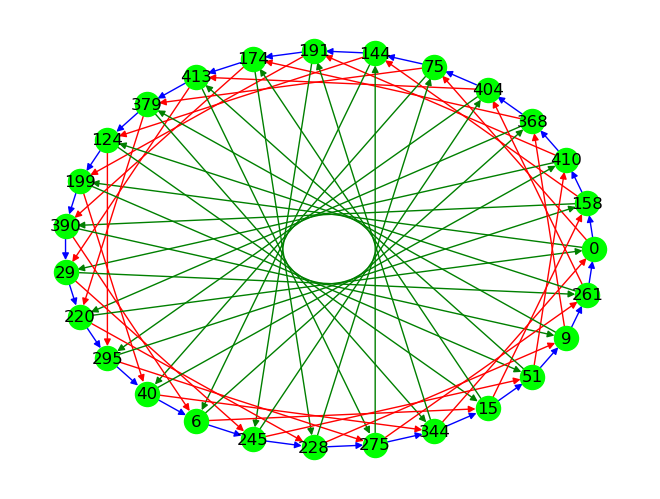

In [18]:
G419 = graf_crear([l1, l2, l3], ["blue", "green", "red"])
graf_dibuixar(G419, with_labels=True)

També, com a l'exemple anterior, donarem la distribució de claus, generant així la Taula 3.2 de la memòria.

In [19]:
distribucio_claus(len(ls), max_exp)

{413: [(-1, -1, -1)],
 29: [(-1, -1, 0)],
 245: [(-1, -1, 1)],
 275: [(-1, 0, -1), (1, -1, 1)],
 261: [(-1, 0, 0)],
 404: [(-1, 0, 1)],
 144: [(-1, 1, -1), (1, 0, 1)],
 124: [(-1, 1, 0), (1, -1, -1)],
 295: [(-1, 1, 1), (1, -1, 0)],
 379: [(0, -1, -1)],
 220: [(0, -1, 0)],
 228: [(0, -1, 1)],
 344: [(0, 0, -1)],
 0: [(0, 0, 0)],
 75: [(0, 0, 1)],
 191: [(0, 1, -1)],
 199: [(0, 1, 0)],
 40: [(0, 1, 1)],
 15: [(1, 0, -1)],
 158: [(1, 0, 0)],
 174: [(1, 1, -1)],
 390: [(1, 1, 0)],
 6: [(1, 1, 1)]}


De nou, executarem un intercanvi de clau, amb els nous paràmetres.  



In [20]:
csidh([1,1,-1], [0,-1,1])

Clau privada de n'Alba:      1  1 -1
Clau pública de n'Alba:     174
Clau privada d'en Biel:      0 -1  1
Clau pública d'en Biel:     228
Secret compartit (Alba):    158
Secret compartit (Biel):    158

--> EL SECRET COINCIDEIX!


Es pot seguir el procediment damunt el graf de manera anàloga a l'intercanvi de clau anterior.  



## Exemple utilitzant 4 primers



A continuació donam un exemple un poc més gran, utilitzant 4 primers ($n=4$). Encara així, l'exemple segueix essent prou petit com per poder determinar el conjunt de corbes de Montgomery supersingulars i representar els grafs $G^{(\ell_i)}$.

El procediment és completament anàleg als exemples anteriors.

In [21]:
set_params([3, 7, 11, 13])
corbes = montgomery_supersingulars()
print()
print(f"Corbes supersingulars ({len(corbes)}):")
print(corbes)

Primers: 3 7 11 13
p = 12011
Rang per als exponents: {-2,...,2}

Corbes supersingulars (195):
[0, 6, 12005, 155, 11856, 208, 11803, 289, 11722, 350, 11661, 363, 11648, 445, 11566, 494, 11517, 544, 11467, 678, 11333, 684, 11327, 693, 11318, 696, 11315, 798, 11213, 801, 11210, 913, 11098, 923, 11088, 1229, 10782, 1242, 10769, 1266, 10745, 1379, 10632, 1408, 10603, 1489, 10522, 1523, 10488, 1551, 10460, 1703, 10308, 1835, 10176, 1893, 10118, 2099, 9912, 2160, 9851, 2169, 9842, 2310, 9701, 2392, 9619, 2450, 9561, 2478, 9533, 2501, 9510, 2510, 9501, 2531, 9480, 2600, 9411, 2744, 9267, 2779, 9232, 2829, 9182, 2859, 9152, 2876, 9135, 2903, 9108, 2951, 9060, 3061, 8950, 3284, 8727, 3382, 8629, 3396, 8615, 3425, 8586, 3486, 8525, 3733, 8278, 3765, 8246, 3780, 8231, 3895, 8116, 3948, 8063, 3954, 8057, 3955, 8056, 3982, 8029, 4034, 7977, 4066, 7945, 4074, 7937, 4082, 7929, 4109, 7902, 4112, 7899, 4128, 7883, 4134, 7877, 4157, 7854, 4201, 7810, 4206, 7805, 4260, 7751, 4332, 7679, 4440, 7571, 4478,

In [22]:
l1 = cicles_accio(corbes, [1,0,0,0])
l2 = cicles_accio(corbes, [0,1,0,0])
l3 = cicles_accio(corbes, [0,0,1,0])
l4 = cicles_accio(corbes, [0,0,0,1])

# (no mostram els cicles per la gran quantitat de nodes)
print(f"Acció per l1: {len(l1)} cicles")
print(f"Acció per l2: {len(l2)} cicles")
print(f"Acció per l3: {len(l3)} cicles")
print(f"Acció per l4: {len(l4)} cicles")


Acció per l1: 5 cicles
Acció per l2: 1 cicles
Acció per l3: 1 cicles
Acció per l4: 5 cicles


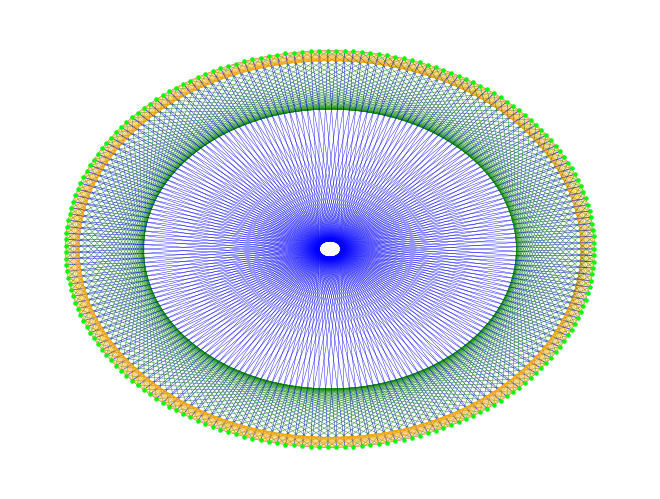

In [23]:
# Posam primer l3 per a què el graf quedi millor
# El dibuixarem sense labels ni fletxes, i amb nodes i arestes més petits, idò el graf és més gran
G12011 = graf_crear([l3, l1, l2, l4], ["red", "blue", "green", "orange"])
graf_dibuixar(G12011, with_labels=False, node_size=5, width=0.3, arrows=False)

En aquest exemple no donarem la distribució de claus, ja que és un poc llarga (hi ha 195 claus públiques) i tampoc no inclourem aquest exemple a la memòria.


De nou, executarem un intercanvi de clau, amb els nous paràmetres. Aquesta vegada no es pot seguir el camí al graf fàcilment per la quantitat de nodes, però el procediment és el mateix.



In [24]:
csidh([-2,-1,0,1], [0,0,2,-2])

Clau privada de n'Alba:     -2 -1  0  1
Clau pública de n'Alba:     2876
Clau privada d'en Biel:      0  0  2 -2
Clau pública d'en Biel:     4157
Secret compartit (Alba):    7805
Secret compartit (Biel):    7805

--> EL SECRET COINCIDEIX!


## Exemple real amb CSIDH-512

Finalment, emprarem els paràmetres de CSIDH-512 per donar un exemple real. Òbviament no podem determinar el conjunt de corbes de Montgomery supersingulars ni els grafs, però sí podem configurar els paràmetres i executar un intercanvi de clau (que a la pràctica és l'únic que ens interessa).

Cal tenir en compte que en aquest quadern hem implementat CSIDH en Sage i, a més, no hem emprat ni l'aritmètica de Montgomery ni els twists quadràtics. Per tant, l'intercanvi de clau serà relativament lent.

In [25]:
# Clau privada de n'Alba (74 enters entre -5 i 5)
privA = [
    0, 1, 0, 4,-1,-1, 0, 0, 2, 2,-1,-2, 1, 2,-1, 0, 0, 1,-2,
    2, 0, 1, 0, 1,-1, 0, 0, 0,-2,-4, 1, 0, 1, 2, 0,-1, 1, 1,
    1, 1, 1,-3, 1,-2, 0, 0, 3,-2,-3, 0, 0, 2,-1, 5,-1,-2, 1,
    1,-1,-2,-1, 2,-3,-1, 1, 0, 1, 0,-3, 0, 0, 1, 0,-1
]

# Clau privada d'en Biel (74 enters entre -5 i 5)
privB = [
    -1, 1, 1,-1,-1,-1, 1,-2,-1, 0, 2, 0,-1, 0, 4,-3, 0, 1, 1,
    +0, 0,-2,-1, 0,-2,-1, 0,-1, 0, 2,-1, 4, 0, 1, 1, 0,-1,-1,
    -1, 1,-2,-2,-1, 1, 0, 0,-1, 1,-1, 5, 0, 0, 1, 0, 0,-2, 0,
    -1, 3, 3, 0, 0,-1, 1,-1, 1, 0, 0,-5, 0, 0, 0, 1, 0
]

# Configuram els paràmetres i executam l'intercanvi de clau
set_params(list(primes(3, 374)) + [587])
csidh(privA, privB)


Primers: 3 5 7 11 13 17 19 23 29 31 37 41 43 47 53 59 61 67 71 73 79 83 89 97 101 103 107 109 113 127 131 137 139 149 151 157 163 167 173 179 181 191 193 197 199 211 223 227 229 233 239 241 251 257 263 269 271 277 281 283 293 307 311 313 317 331 337 347 349 353 359 367 373 587
p = 5326738796327623094747867617954605554069371494832722337612446642054009560026576537626892113026381253624626941643949444792662881241621373288942880288065659
Rang per als exponents: {-5,...,5}
Clau privada de n'Alba:      0  1  0  4 -1 -1  0  0  2  2 -1 -2  1  2 -1  0  0  1 -2  2  0  1  0  1 -1  0  0  0 -2 -4  1  0  1  2  0 -1  1  1  1  1  1 -3  1 -2  0  0  3 -2 -3  0  0  2 -1  5 -1 -2  1  1 -1 -2 -1  2 -3 -1  1  0  1  0 -3  0  0  1  0 -1
Clau pública de n'Alba:     4651537770041097669063201123339059794591715308311233518709163477488961971656394300898167282899753225411529563679103711779400250372464889960187351899144943
Clau privada d'en Biel:     -1  1  1 -1 -1 -1  1 -2 -1  0  2  0 -1  0  4 -3  0  1  1  0  0 -2 -

## Extra: grafs a tikz

Els grafs G83 i G419 els incorporarem a la memòria. Per tant, crearem una funció auxiliar per obtenir el codi tikz corresponent.

In [26]:
# Converteix un graf de CSIDH a tikz
def grafTikz(G, escala, escalalab):
        pos = nx.circular_layout(G)  # Plantilla circular
        print('\\begin{tikzpicture}')

        # Dibuixam els nodes
        for node in G.nodes():
            x = pos[node][0] * escala
            y = pos[node][1] * escala
            print(f'\\node[circle, draw, fill=black, inner sep=1.5pt] ({node}) at ({x:.2f}, {y:.2f}) {{}};')

            # Dibuixam l'etiqueta dels nodes fora del mateix (escalant les coordenades)
            x = pos[node][0] * escalalab
            y = pos[node][1] * escalalab
            print(f'\\node (lab{node}) at ({x:.2f}, {y:.2f}) {{{node}}};')

        # Dibuixam les arestes
        for edge in G.edges():
            color = G[edge[0]][edge[1]]["color"]
            print(f'\\draw[->, line width=0.4mm, {color}] ({edge[0]}) -- ({edge[1]});')

        print('\\end{tikzpicture}\n')

In [27]:
grafTikz(G83, 3, 3.4)

\begin{tikzpicture}
\node[circle, draw, fill=black, inner sep=1.5pt] (0) at (3.00, 0.00) {};
\node (lab0) at (3.40, 0.00) {0};
\node[circle, draw, fill=black, inner sep=1.5pt] (72) at (2.30, 1.93) {};
\node (lab72) at (2.60, 2.19) {72};
\node[circle, draw, fill=black, inner sep=1.5pt] (71) at (0.52, 2.95) {};
\node (lab71) at (0.59, 3.35) {71};
\node[circle, draw, fill=black, inner sep=1.5pt] (77) at (-1.50, 2.60) {};
\node (lab77) at (-1.70, 2.94) {77};
\node[circle, draw, fill=black, inner sep=1.5pt] (13) at (-2.82, 1.03) {};
\node (lab13) at (-3.19, 1.16) {13};
\node[circle, draw, fill=black, inner sep=1.5pt] (70) at (-2.82, -1.03) {};
\node (lab70) at (-3.19, -1.16) {70};
\node[circle, draw, fill=black, inner sep=1.5pt] (6) at (-1.50, -2.60) {};
\node (lab6) at (-1.70, -2.94) {6};
\node[circle, draw, fill=black, inner sep=1.5pt] (12) at (0.52, -2.95) {};
\node (lab12) at (0.59, -3.35) {12};
\node[circle, draw, fill=black, inner sep=1.5pt] (11) at (2.30, -1.93) {};
\node (lab11) at 

In [28]:
grafTikz(G419, 5, 5.5)

\begin{tikzpicture}
\node[circle, draw, fill=black, inner sep=1.5pt] (0) at (5.00, 0.00) {};
\node (lab0) at (5.50, 0.00) {0};
\node[circle, draw, fill=black, inner sep=1.5pt] (158) at (4.87, 1.15) {};
\node (lab158) at (5.35, 1.27) {158};
\node[circle, draw, fill=black, inner sep=1.5pt] (410) at (4.47, 2.24) {};
\node (lab410) at (4.91, 2.47) {410};
\node[circle, draw, fill=black, inner sep=1.5pt] (368) at (3.83, 3.21) {};
\node (lab368) at (4.21, 3.54) {368};
\node[circle, draw, fill=black, inner sep=1.5pt] (404) at (2.99, 4.01) {};
\node (lab404) at (3.28, 4.41) {404};
\node[circle, draw, fill=black, inner sep=1.5pt] (75) at (1.98, 4.59) {};
\node (lab75) at (2.18, 5.05) {75};
\node[circle, draw, fill=black, inner sep=1.5pt] (144) at (0.87, 4.92) {};
\node (lab144) at (0.96, 5.42) {144};
\node[circle, draw, fill=black, inner sep=1.5pt] (191) at (-0.29, 4.99) {};
\node (lab191) at (-0.32, 5.49) {191};
\node[circle, draw, fill=black, inner sep=1.5pt] (174) at (-1.43, 4.79) {};
\node (